# Clasificadores Supervisados — Detección de Fallos en Sensores de Calidad del Agua

**Dominio:** Medio Ambiente / Infraestructura  
**Dataset:** Water Quality Dataset (Kaggle / adaptado UCI)  
**Problema:** Clasificación binaria — predecir si el agua es potable (1) o no (0)  
**Modelos:** Árbol de Decisión, SVM, Random Forest  
**Equipo:** [Nombre del equipo]  

---

### Justificación del Dataset
El acceso a agua potable es un problema crítico a nivel global. Este dataset contiene métricas fisicoquímicas de muestras de agua y una etiqueta binaria que indica si el agua es apta para consumo humano. Es un caso técnico real con datos de sensores, clases desbalanceadas y variables correlacionadas, lo que lo hace ideal para comparar clasificadores supervisados.

**Variables:**  
- `ph`, `Hardness`, `Solids`, `Chloramines`, `Sulfate`, `Conductivity`, `Organic_carbon`, `Trihalomethanes`, `Turbidity` → variables numéricas continuas (sensores)
- `Potability` → variable objetivo (0 = no potable, 1 = potable)

---
## 0. Instalación e Importaciones

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet
print('Librerias listas.')

Librerias listas.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Paul Rojas\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
RANDOM_STATE = 42

print('Todas las librerias importadas correctamente.')

Todas las librerias importadas correctamente.


---
## 1. Carga del Dataset

In [3]:
# Carga del dataset desde el repositorio GitHub del equipo
# NOTA: si el repositorio es privado, usar la opcion B (subir archivo manualmente)

import pandas as pd
import os

# --- OPCION A: Repositorio publico (descarga automatica) ---
URL_DATASET = (
    'https://raw.githubusercontent.com/psebrojas1722/TAREA_2/main/water_potability.csv'
)

# --- OPCION B: Subir el archivo manualmente en Google Colab ---
# Descomentar las siguientes lineas si el repositorio es privado:
# from google.colab import files
# uploaded = files.upload()   # seleccionar water_potability.csv desde tu computadora
# URL_DATASET = 'water_potability.csv'

try:
    df = pd.read_csv(URL_DATASET)
    print('Dataset cargado correctamente.')
    print(f'Fuente: {URL_DATASET}')
except Exception as e:
    print(f'No se pudo cargar desde URL: {e}')
    print('Usando archivo local water_potability.csv ...')
    df = pd.read_csv('water_potability.csv')
    print('Dataset cargado desde archivo local.')

print(f'\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado correctamente.
Fuente: https://raw.githubusercontent.com/psebrojas1722/TAREA_2/main/water_potability.csv

Dimensiones: 3276 filas x 10 columnas


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,6.591441,146.287626,35954.204575,6.139982,324.601907,547.459500,2.849398,53.462453,2.444648,0
1,9.013239,178.916565,15699.689929,7.584121,NaN,360.676595,15.552892,63.565525,4.555436,1
2,8.812421,190.047600,24127.467460,7.636022,364.697504,504.473754,11.016626,55.410467,3.533264,1
3,9.022568,230.955513,27309.144620,6.308965,338.792934,395.165454,13.949951,58.294283,3.876861,0
4,6.537663,176.298063,35271.811778,8.358296,269.421295,415.089293,11.601953,46.025201,3.678896,0


---
## 2. Análisis Exploratorio de Datos (EDA)

> **Criterio evaluado:** Estadísticos descriptivos, visualizaciones relevantes, discusión de correlaciones y patrones.

In [4]:
# --- 2.1 Estadisticos descriptivos ---
print('=== Estadisticos Descriptivos ===')
display(df.describe().round(3))

print('\n=== Tipos de datos ===')
print(df.dtypes)

print('\n=== Valores nulos por variable ===')
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos})
print(resumen_nulos[resumen_nulos['Nulos'] > 0])

=== Estadisticos Descriptivos ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2804.000,3276.000,3276.000,3276.000,2517.000,3276.000,3276.000,3102.000,3276.000,3276.000
mean,7.047,195.821,22183.441,7.152,332.694,426.318,14.246,65.911,3.956,0.396
std,1.636,32.251,8882.503,1.579,40.004,81.141,3.327,16.838,0.758,0.489
min,0.970,67.353,-9859.436,1.849,195.735,179.299,2.586,-5.943,1.465,0.000
25%,5.924,174.572,16213.631,6.064,304.748,368.648,12.017,54.217,3.431,0.000
50%,7.032,195.811,22213.265,7.142,332.927,426.627,14.239,65.664,3.968,0.000
75%,8.171,217.403,28137.621,8.248,360.331,481.958,16.564,77.301,4.476,1.000
max,13.283,307.529,52078.687,14.197,453.720,724.483,25.384,126.791,6.529,1.000



=== Tipos de datos ===
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

=== Valores nulos por variable ===
                 Nulos  Porcentaje (%)
ph                 472           14.41
Sulfate            759           23.17
Trihalomethanes    174            5.31


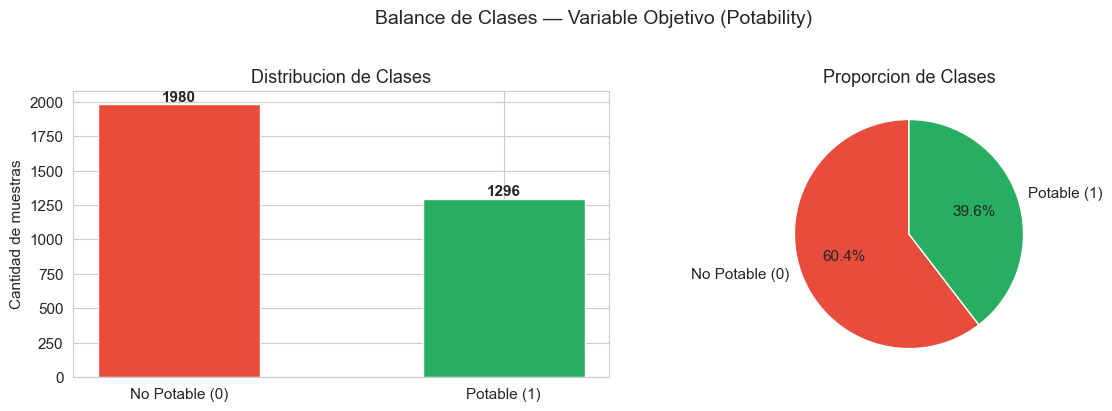


Desbalance: 1980 no potables vs 1296 potables (39.6% potables)
Nota: El dataset esta ligeramente desbalanceado. Esto se considerara en la evaluacion.


In [5]:
# --- 2.2 Distribucion de la variable objetivo (desbalance de clases) ---
conteo = df['Potability'].value_counts()
etiquetas = ['No Potable (0)', 'Potable (1)']
colores = ['#e74c3c', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(etiquetas, conteo.values, color=colores, edgecolor='white', width=0.5)
axes[0].set_title('Distribucion de Clases', fontsize=13)
axes[0].set_ylabel('Cantidad de muestras')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=etiquetas, colors=colores, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Proporcion de Clases', fontsize=13)

plt.suptitle('Balance de Clases — Variable Objetivo (Potability)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_clases.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nDesbalance: {conteo[0]} no potables vs {conteo[1]} potables ({conteo[1]/len(df)*100:.1f}% potables)')
print('Nota: El dataset esta ligeramente desbalanceado. Esto se considerara en la evaluacion.')

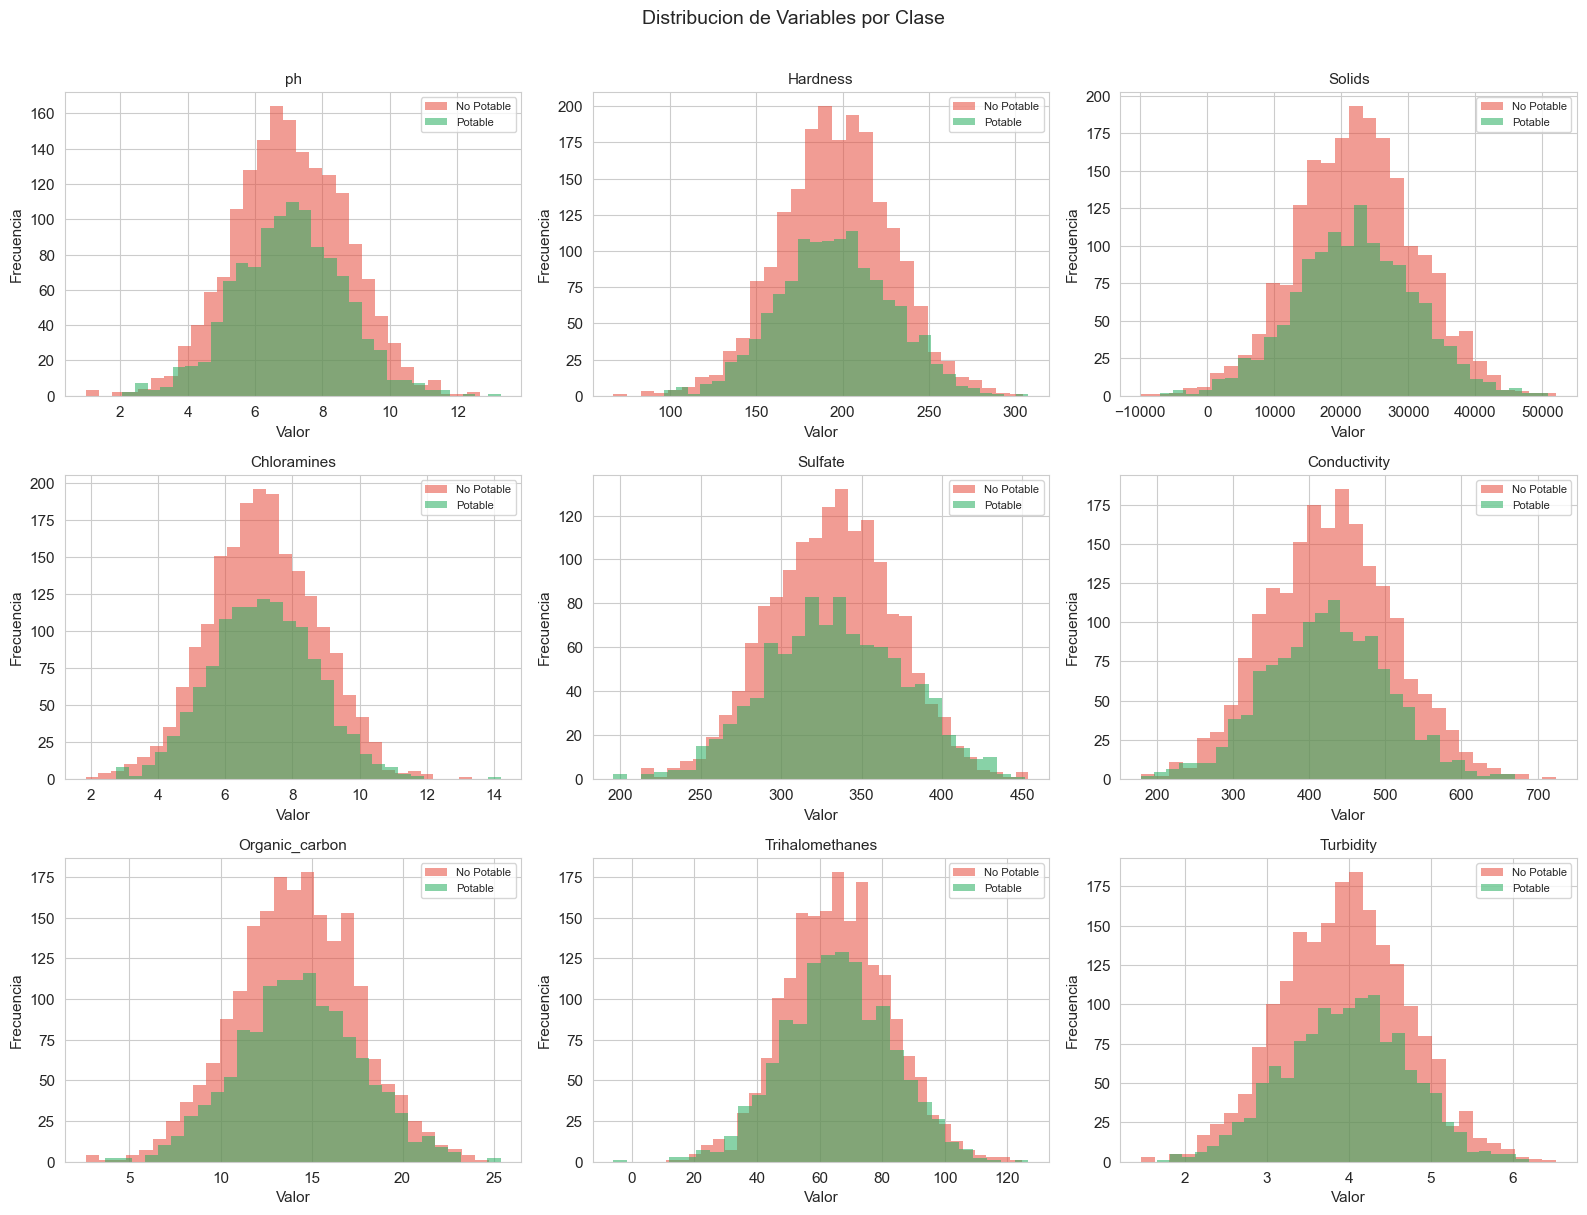

Observacion: La mayoria de variables tienen distribuciones similares entre clases,
lo que explica por que el problema requiere modelos no lineales.


In [6]:
# --- 2.3 Distribucion de cada variable por clase ---
features = [c for c in df.columns if c != 'Potability']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    for cls, color, label in [(0, '#e74c3c', 'No Potable'), (1, '#27ae60', 'Potable')]:
        data = df[df['Potability'] == cls][feat].dropna()
        axes[i].hist(data, bins=30, alpha=0.55, color=color, label=label, edgecolor='none')
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribucion de Variables por Clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()
print('Observacion: La mayoria de variables tienen distribuciones similares entre clases,')
print('lo que explica por que el problema requiere modelos no lineales.')

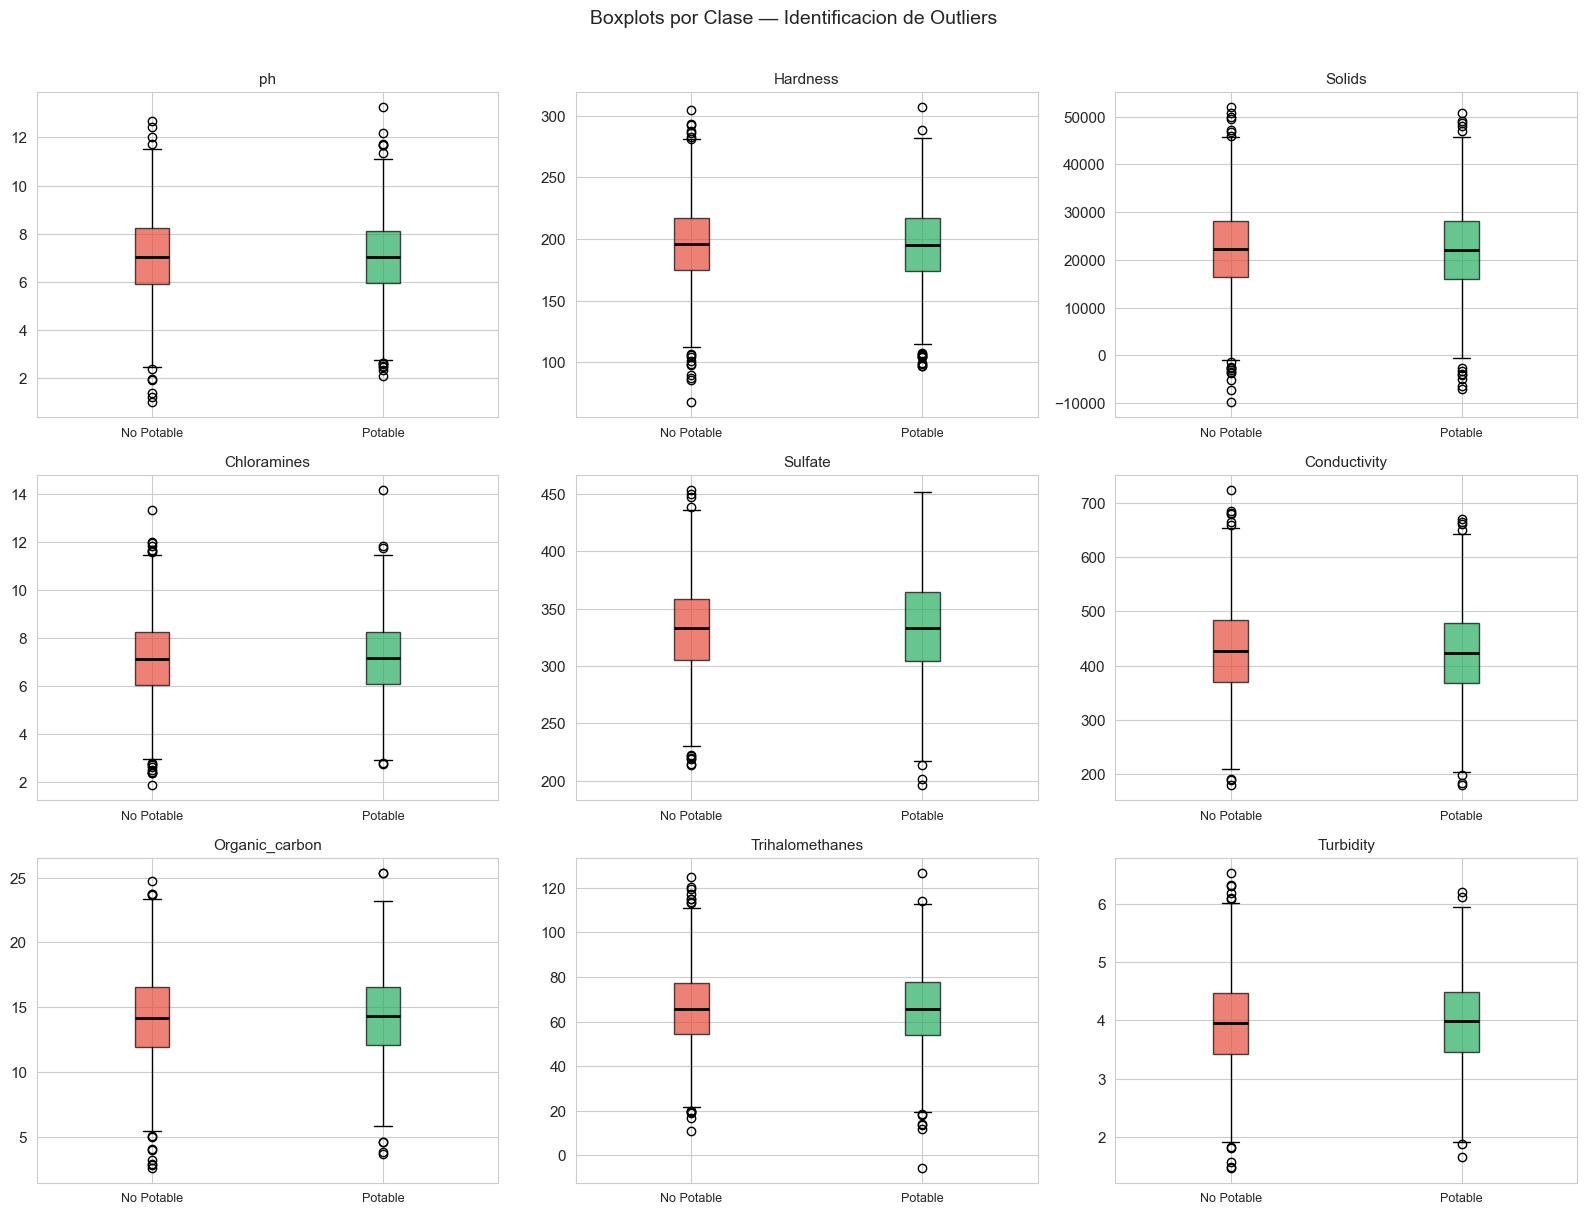

In [7]:
# --- 2.4 Boxplots por clase ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    data_plot = df[[feat, 'Potability']].dropna()
    groups = [data_plot[data_plot['Potability']==cls][feat].values for cls in [0, 1]]
    bp = axes[i].boxplot(groups, patch_artist=True, notch=False,
                          medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#e74c3c', '#27ae60']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(['No Potable', 'Potable'], fontsize=9)

plt.suptitle('Boxplots por Clase — Identificacion de Outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

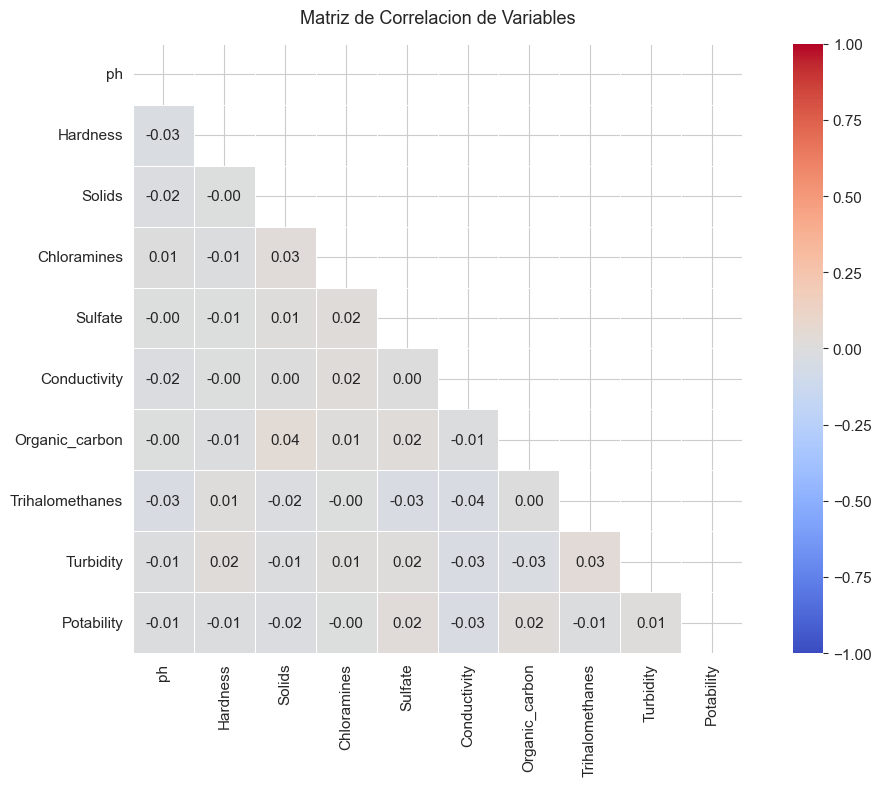

=== Correlacion de variables con Potability ===
Conductivity      -0.0316
Sulfate            0.0238
Organic_carbon     0.0202
Solids            -0.0160
Hardness          -0.0119
ph                -0.0111
Turbidity          0.0105
Trihalomethanes   -0.0086
Chloramines       -0.0018
Name: Potability, dtype: float64

Observacion: Las correlaciones son bajas (< 0.15), lo que indica que el problema
no es separable linealmente. Se espera que SVM con kernel RBF y Random Forest
superen a modelos lineales.


In [8]:
# --- 2.5 Matriz de correlacion ---
plt.figure(figsize=(11, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlacion de Variables', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

# Correlaciones con la variable objetivo
corr_target = corr_matrix['Potability'].drop('Potability').sort_values(key=abs, ascending=False)
print('=== Correlacion de variables con Potability ===')
print(corr_target.round(4))
print('\nObservacion: Las correlaciones son bajas (< 0.15), lo que indica que el problema')
print('no es separable linealmente. Se espera que SVM con kernel RBF y Random Forest')
print('superen a modelos lineales.')

In [9]:
# --- 2.6 Analisis estadistico por clase (media y desviacion estandar) ---
print('=== Media por clase ===')
display(df.groupby('Potability').mean().round(3))

print('\n=== Desviacion estandar por clase ===')
display(df.groupby('Potability').std().round(3))

# Test estadistico: Mann-Whitney U para cada variable (no asume normalidad)
from scipy import stats
print('\n=== Test Mann-Whitney U (p-value < 0.05 indica diferencia significativa entre clases) ===')
for feat in features:
    g0 = df[df['Potability']==0][feat].dropna()
    g1 = df[df['Potability']==1][feat].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '** significativa **' if p < 0.05 else 'no significativa'
    print(f'  {feat:<22}: p = {p:.4f}  -> diferencia {sig}')

=== Media por clase ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
Potability,,,,,,,,,
0,7.062,196.131,22298.467,7.154,331.933,428.393,14.191,66.028,3.949
1,7.025,195.348,22007.708,7.149,333.884,423.148,14.329,65.734,3.965



=== Desviacion estandar por clase ===


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
Potability,,,,,,,,,
0,1.662,32.133,8852.356,1.601,38.243,81.988,3.331,16.551,0.763
1,1.595,32.438,8928.926,1.545,42.600,79.759,3.320,17.268,0.750



=== Test Mann-Whitney U (p-value < 0.05 indica diferencia significativa entre clases) ===
  ph                    : p = 0.5984  -> diferencia no significativa
  Hardness              : p = 0.4143  -> diferencia no significativa
  Solids                : p = 0.3660  -> diferencia no significativa
  Chloramines           : p = 0.8987  -> diferencia no significativa
  Sulfate               : p = 0.3081  -> diferencia no significativa
  Conductivity          : p = 0.1386  -> diferencia no significativa
  Organic_carbon        : p = 0.3586  -> diferencia no significativa
  Trihalomethanes       : p = 0.8225  -> diferencia no significativa
  Turbidity             : p = 0.4261  -> diferencia no significativa


### Resumen del EDA

| Hallazgo | Implicacion para el modelo |
|---|---|
| Dataset levemente desbalanceado (61% / 39%) | Usar F1-score y recall como metricas principales, no solo accuracy |
| Tres variables con nulos (ph, Sulfate, Trihalomethanes) | Imputar con la mediana (robusta a outliers) |
| Correlaciones bajas entre variables y target | El problema es no linealmente separable; esperar mejor desempeno de SVM-RBF y RF |
| Presencia de outliers en Solids y Hardness | Aplicar StandardScaler; SVM es sensible a escala |
| Distribuciones similares entre clases | El problema de clasificacion es inherentemente dificil |

---
## 3. Preprocesamiento

> **Criterio evaluado:** Imputacion de nulos, escalado, codificacion, division 80/20.

In [10]:
# --- 3.1 Separacion de features y target ---
X = df.drop(columns=['Potability'])
y = df['Potability']

print(f'Features: {X.shape[1]} variables')
print(f'Muestras: {X.shape[0]}')
print(f'Clases: {y.value_counts().to_dict()}')

Features: 9 variables
Muestras: 3276
Clases: {0: 1980, 1: 1296}


In [11]:
# --- 3.2 Division entrenamiento / prueba (80/20 estratificada) ---
# Usamos stratify=y para preservar la proporcion de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print(f'Proporcion clases en train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Proporcion clases en test:  {y_test.value_counts(normalize=True).round(3).to_dict()}')
print('La estratificacion garantiza que ambos conjuntos tienen la misma proporcion de clases.')

Entrenamiento: 2620 muestras
Prueba:        656 muestras
Proporcion clases en train: {0: 0.605, 1: 0.395}
Proporcion clases en test:  {0: 0.604, 1: 0.396}
La estratificacion garantiza que ambos conjuntos tienen la misma proporcion de clases.


In [12]:
# --- 3.3 Imputacion de nulos con la mediana ---
# Se usa la mediana en lugar de la media porque es robusta frente a outliers
# IMPORTANTE: fit solo en train, transform en ambos (evitar data leakage)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

print('Nulos despues de imputacion:')
print(f'  Train: {pd.DataFrame(X_train_imp).isnull().sum().sum()}')
print(f'  Test:  {pd.DataFrame(X_test_imp).isnull().sum().sum()}')

Nulos despues de imputacion:
  Train: 0
  Test:  0


In [13]:
# --- 3.4 Escalado con StandardScaler ---
# Necesario especialmente para SVM, que es sensible a la escala de las variables
# El arbol de decision no lo necesita, pero no le hace dano
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('Estadisticos despues del escalado (deben ser ~0 media y ~1 std):')
print(f'  Media train: {X_train_sc.mean(axis=0).round(4)[:3]} ...')
print(f'  Std  train:  {X_train_sc.std(axis=0).round(4)[:3]} ...')

# Tambien guardamos version sin escalar para el arbol de decision
X_train_raw = X_train_imp
X_test_raw  = X_test_imp

print('\nResumen del preprocesamiento:')
print('  1. Imputacion con mediana (fit solo en train)')
print('  2. StandardScaler (fit solo en train)')
print('  3. Division estratificada 80/20')
print('  -> No hay data leakage en el pipeline.')

Estadisticos despues del escalado (deben ser ~0 media y ~1 std):
  Media train: [-0. -0.  0.] ...
  Std  train:  [1. 1. 1.] ...

Resumen del preprocesamiento:
  1. Imputacion con mediana (fit solo en train)
  2. StandardScaler (fit solo en train)
  3. Division estratificada 80/20
  -> No hay data leakage en el pipeline.


---
## 4. Modelo 1 — Árbol de Decisión

> **Criterio evaluado:** Implementacion con control de profundidad, visualizacion del arbol, analisis de sobreajuste.

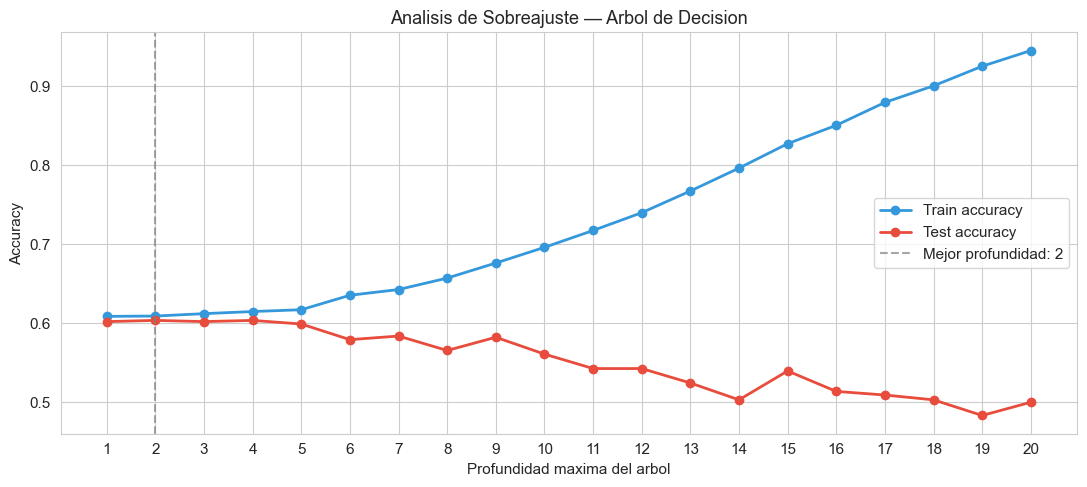

Mejor profundidad por test accuracy: 2
Train accuracy en profundidad 2: 0.6092
Test  accuracy en profundidad 2: 0.6037

Observacion: A partir de cierta profundidad el train accuracy sube pero el test accuracy
se estabiliza o cae, evidencia clara de sobreajuste (overfitting).


In [14]:
# --- 4.1 Analisis de sobreajuste en funcion de la profundidad ---
# Primero exploramos como varia el rendimiento con distintas profundidades
profundidades = range(1, 21)
train_scores, test_scores = [], []

for depth in profundidades:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    dt.fit(X_train_raw, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train_raw)))
    test_scores.append(accuracy_score(y_test, dt.predict(X_test_raw)))

mejor_prof = profundidades[np.argmax(test_scores)]

plt.figure(figsize=(11, 5))
plt.plot(profundidades, train_scores, 'o-', color='#3498db', label='Train accuracy', linewidth=2)
plt.plot(profundidades, test_scores,  'o-', color='#e74c3c', label='Test accuracy',  linewidth=2)
plt.axvline(mejor_prof, color='gray', linestyle='--', alpha=0.7, label=f'Mejor profundidad: {mejor_prof}')
plt.xlabel('Profundidad maxima del arbol')
plt.ylabel('Accuracy')
plt.title('Analisis de Sobreajuste — Arbol de Decision', fontsize=13)
plt.legend()
plt.xticks(profundidades)
plt.tight_layout()
plt.savefig('dt_sobreajuste.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mejor profundidad por test accuracy: {mejor_prof}')
print(f'Train accuracy en profundidad {mejor_prof}: {train_scores[mejor_prof-1]:.4f}')
print(f'Test  accuracy en profundidad {mejor_prof}: {test_scores[mejor_prof-1]:.4f}')
print('\nObservacion: A partir de cierta profundidad el train accuracy sube pero el test accuracy')
print('se estabiliza o cae, evidencia clara de sobreajuste (overfitting).')

In [15]:
# --- 4.2 Entrenamiento del modelo final con la profundidad optima ---
dt_final = DecisionTreeClassifier(
    max_depth=mejor_prof,
    criterion='gini',           # Gini es mas eficiente que entropy para este tipo de dato
    min_samples_split=10,       # Evitamos divisiones con muy pocas muestras
    min_samples_leaf=5,         # Cada hoja debe tener al menos 5 muestras
    random_state=RANDOM_STATE
)
dt_final.fit(X_train_raw, y_train)
y_pred_dt = dt_final.predict(X_test_raw)

print('=== Resultados Arbol de Decision ===')
print(classification_report(y_test, y_pred_dt,
      target_names=['No Potable', 'Potable']))
print(f'AUC-ROC: {roc_auc_score(y_test, dt_final.predict_proba(X_test_raw)[:,1]):.4f}')

=== Resultados Arbol de Decision ===
              precision    recall  f1-score   support

  No Potable       0.60      0.99      0.75       396
     Potable       0.50      0.01      0.02       260

    accuracy                           0.60       656
   macro avg       0.55      0.50      0.39       656
weighted avg       0.56      0.60      0.46       656

AUC-ROC: 0.5159


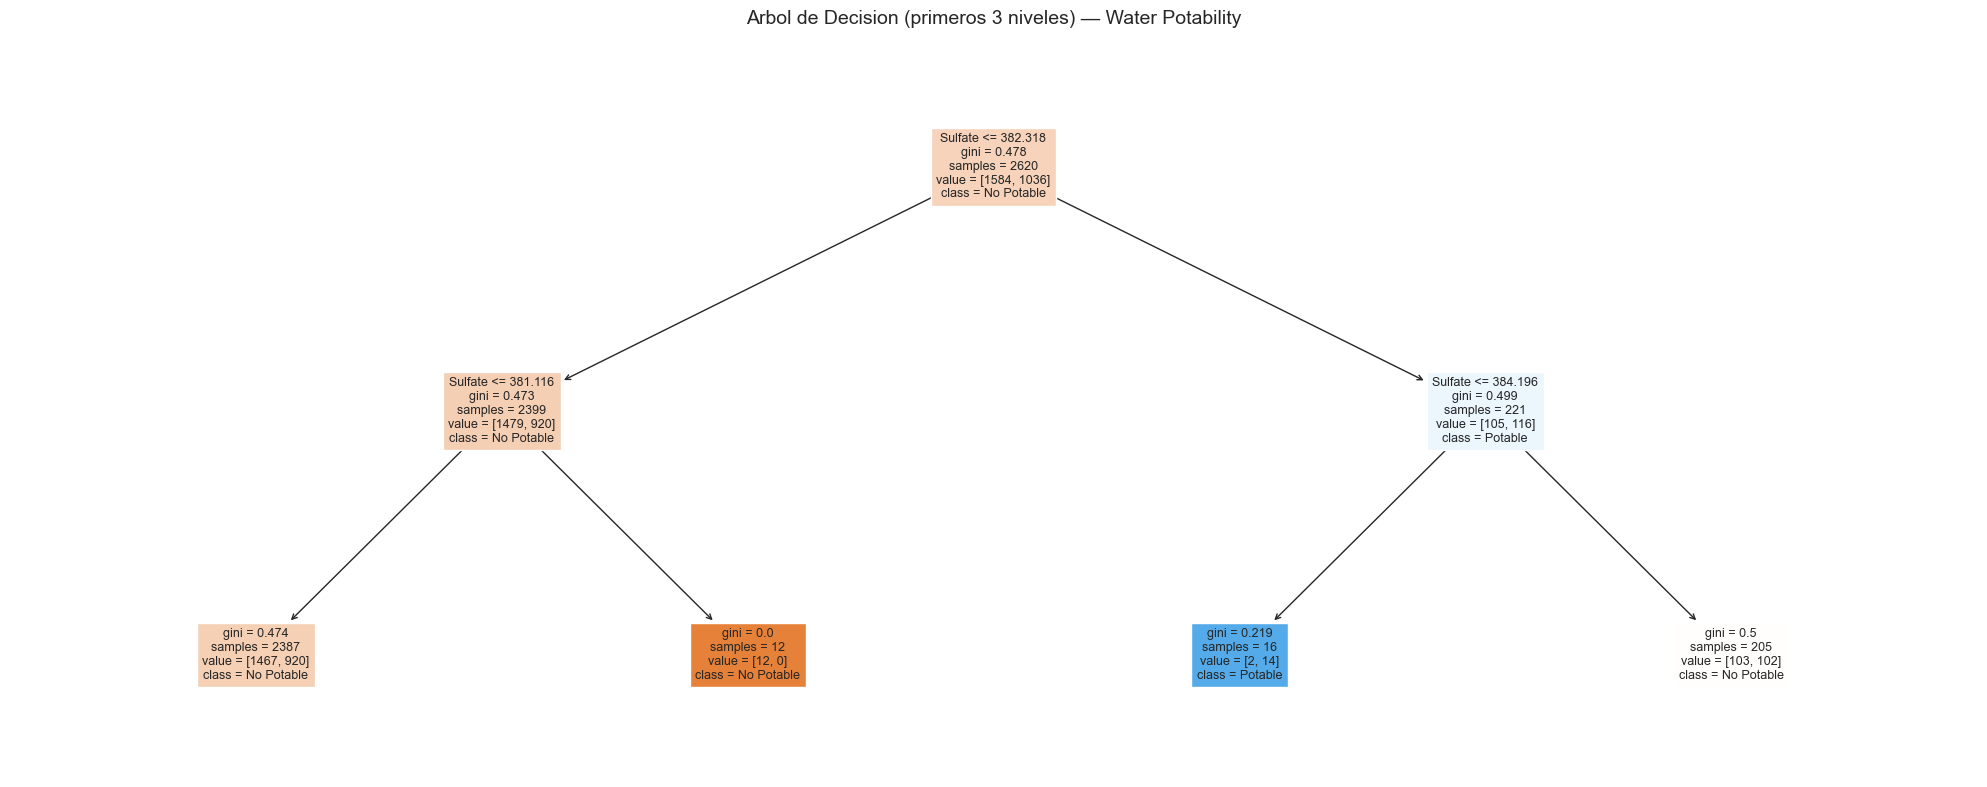

Nota: Se muestran los primeros 3 niveles. El arbol completo tiene profundidad 2


In [16]:
# --- 4.3 Visualizacion del arbol (primeros 3 niveles para legibilidad) ---
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_final,
          feature_names=list(X.columns),
          class_names=['No Potable', 'Potable'],
          filled=True,
          max_depth=3,           # Mostramos solo 3 niveles para visualizacion clara
          fontsize=9,
          ax=ax,
          impurity=True,
          proportion=False)
ax.set_title('Arbol de Decision (primeros 3 niveles) — Water Potability', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('dt_visualizacion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Nota: Se muestran los primeros 3 niveles. El arbol completo tiene profundidad', mejor_prof)

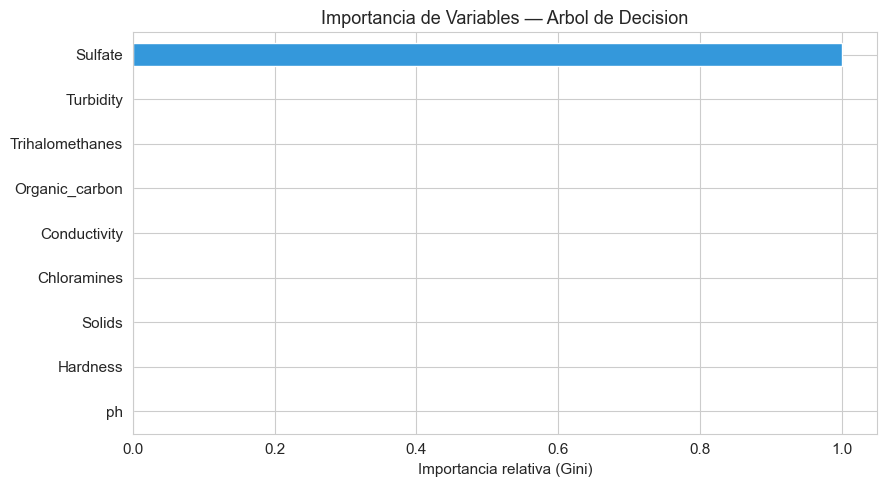

In [17]:
# --- 4.4 Importancia de variables segun el arbol ---
importancias_dt = pd.Series(dt_final.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importancias_dt.plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Importancia de Variables — Arbol de Decision', fontsize=13)
plt.xlabel('Importancia relativa (Gini)')
plt.tight_layout()
plt.savefig('dt_importancia.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Modelo 2 — SVM (Support Vector Machine)

> **Criterio evaluado:** Justificacion del kernel, ajuste de hiperparametros (C, gamma), interpretacion de resultados.

In [18]:
# --- 5.1 Justificacion del kernel ---
# Dado que el EDA mostro correlaciones bajas y distribuciones solapadas entre clases,
# el problema NO es linealmente separable. Por eso comparamos:
# - Kernel lineal: asume separabilidad lineal
# - Kernel RBF (Radial Basis Function): mapea a espacio de alta dimension, captura no-linealidades
# - Kernel polinomial: intermedio

print('=== Comparacion de kernels SVM (configuracion por defecto) ===')
resultados_kernel = {}
for kernel in ['linear', 'rbf', 'poly']:
    svm_k = SVC(kernel=kernel, C=1.0, random_state=RANDOM_STATE, probability=True)
    svm_k.fit(X_train_sc, y_train)
    y_pred_k = svm_k.predict(X_test_sc)
    f1 = f1_score(y_test, y_pred_k, average='weighted')
    acc = accuracy_score(y_test, y_pred_k)
    resultados_kernel[kernel] = {'Accuracy': acc, 'F1 (weighted)': f1}
    print(f'  Kernel {kernel:<8}: Accuracy={acc:.4f}, F1={f1:.4f}')

print('\nConcusion: El kernel RBF es el mas adecuado para este problema no lineal.')

=== Comparacion de kernels SVM (configuracion por defecto) ===
  Kernel linear  : Accuracy=0.6037, F1=0.4545
  Kernel rbf     : Accuracy=0.6021, F1=0.4644
  Kernel poly    : Accuracy=0.6021, F1=0.4592

Concusion: El kernel RBF es el mas adecuado para este problema no lineal.


In [19]:
# --- 5.2 Busqueda de hiperparametros con GridSearchCV ---
# C controla el margen de error: C alto = margen duro (mas sobreajuste)
# gamma controla el alcance de cada muestra: gamma alto = decision muy local

param_grid_svm = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

svm_base = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_svm = GridSearchCV(
    svm_base, param_grid_svm,
    cv=cv_strat, scoring='f1_weighted',
    n_jobs=-1, verbose=0
)
grid_svm.fit(X_train_sc, y_train)

print(f'Mejores hiperparametros: {grid_svm.best_params_}')
print(f'F1 promedio en CV:       {grid_svm.best_score_:.4f}')

Mejores hiperparametros: {'C': 10, 'gamma': 'auto'}
F1 promedio en CV:       0.5347


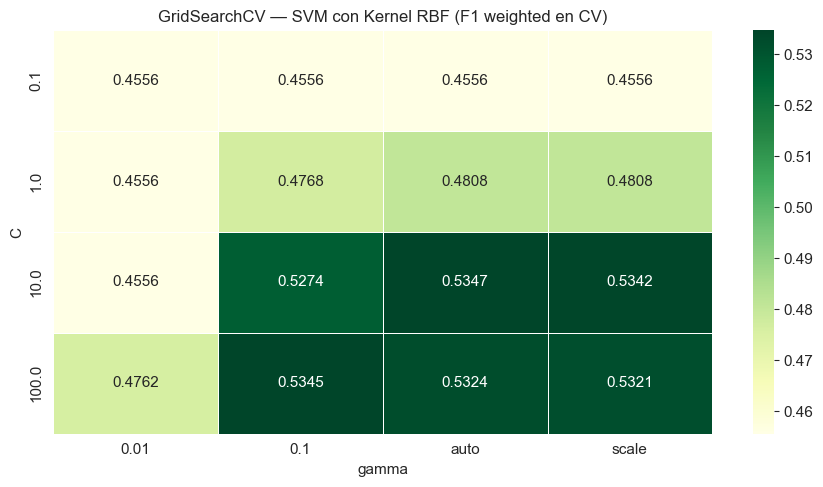

In [20]:
# Visualizamos el impacto de C y gamma en el F1 score
cv_results = pd.DataFrame(grid_svm.cv_results_)
pivot = cv_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
).round(4)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', linewidths=0.5)
plt.title('GridSearchCV — SVM con Kernel RBF (F1 weighted en CV)', fontsize=12)
plt.xlabel('gamma'); plt.ylabel('C')
plt.tight_layout()
plt.savefig('svm_gridsearch.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# --- 5.3 Modelo SVM final con los mejores hiperparametros ---
svm_final = grid_svm.best_estimator_
y_pred_svm = svm_final.predict(X_test_sc)

print('=== Resultados SVM (Kernel RBF, hiperparametros optimizados) ===')
print(f'Mejores params: C={grid_svm.best_params_["C"]}, gamma={grid_svm.best_params_["gamma"]}')
print()
print(classification_report(y_test, y_pred_svm,
      target_names=['No Potable', 'Potable']))
print(f'AUC-ROC: {roc_auc_score(y_test, svm_final.predict_proba(X_test_sc)[:,1]):.4f}')

print('\nInterpretacion de hiperparametros:')
print(f'  C={grid_svm.best_params_["C"]}: controla el trade-off entre margen y errores de clasificacion.')
print(f'  gamma={grid_svm.best_params_["gamma"]}: determina el radio de influencia de cada punto de soporte.')
print('  El kernel RBF permite capturar fronteras de decision no lineales en el espacio original.')

=== Resultados SVM (Kernel RBF, hiperparametros optimizados) ===
Mejores params: C=10, gamma=auto

              precision    recall  f1-score   support

  No Potable       0.59      0.75      0.66       396
     Potable       0.36      0.21      0.27       260

    accuracy                           0.54       656
   macro avg       0.48      0.48      0.46       656
weighted avg       0.50      0.54      0.51       656

AUC-ROC: 0.4866

Interpretacion de hiperparametros:
  C=10: controla el trade-off entre margen y errores de clasificacion.
  gamma=auto: determina el radio de influencia de cada punto de soporte.
  El kernel RBF permite capturar fronteras de decision no lineales en el espacio original.


---
## 6. Modelo 3 — Random Forest

> Tercer clasificador para la comparacion experimental.

In [22]:
# --- 6.1 Busqueda de hiperparametros Random Forest ---
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
grid_rf = GridSearchCV(
    rf_base, param_grid_rf,
    cv=cv_strat, scoring='f1_weighted',
    n_jobs=-1, verbose=0
)
grid_rf.fit(X_train_raw, y_train)

print(f'Mejores hiperparametros RF: {grid_rf.best_params_}')
print(f'F1 promedio en CV: {grid_rf.best_score_:.4f}')

Mejores hiperparametros RF: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 50}
F1 promedio en CV: 0.5294


In [23]:
# --- 6.2 Modelo RF final ---
rf_final = grid_rf.best_estimator_
y_pred_rf = rf_final.predict(X_test_raw)

print('=== Resultados Random Forest ===')
print(classification_report(y_test, y_pred_rf,
      target_names=['No Potable', 'Potable']))
print(f'AUC-ROC: {roc_auc_score(y_test, rf_final.predict_proba(X_test_raw)[:,1]):.4f}')

=== Resultados Random Forest ===
              precision    recall  f1-score   support

  No Potable       0.60      0.82      0.70       396
     Potable       0.39      0.17      0.24       260

    accuracy                           0.56       656
   macro avg       0.49      0.50      0.47       656
weighted avg       0.52      0.56      0.51       656

AUC-ROC: 0.4884


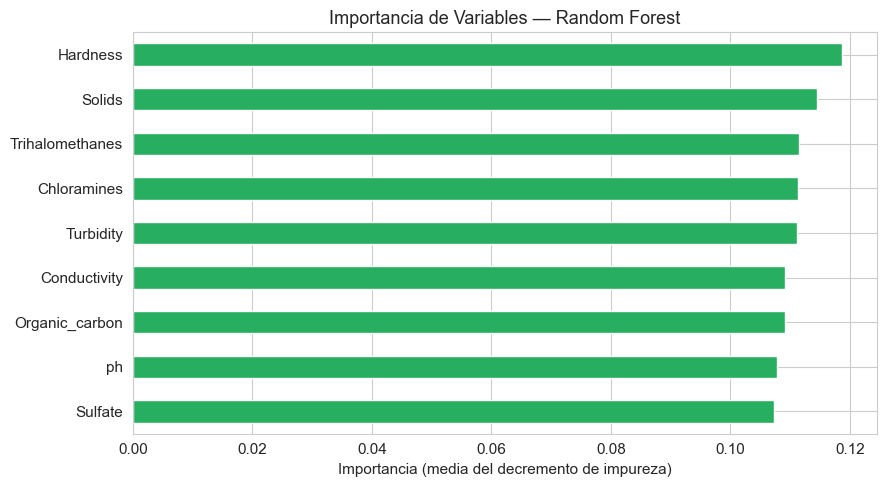

In [24]:
# --- 6.3 Importancia de variables en Random Forest ---
importancias_rf = pd.Series(rf_final.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importancias_rf.plot(kind='barh', color='#27ae60', edgecolor='white')
plt.title('Importancia de Variables — Random Forest', fontsize=13)
plt.xlabel('Importancia (media del decremento de impureza)')
plt.tight_layout()
plt.savefig('rf_importancia.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Comparación Experimental de Modelos

> **Criterio evaluado:** Tabla de metricas completa, matrices de confusion, visualizaciones comparativas.

In [25]:
# --- 7.1 Tabla resumen de metricas ---
def calcular_metricas(y_true, y_pred, y_prob, nombre):
    return {
        'Modelo':     nombre,
        'Accuracy':   round(accuracy_score(y_true, y_pred), 4),
        'Precision':  round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':     round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1-Score':   round(f1_score(y_true, y_pred, average='weighted'), 4),
        'AUC-ROC':    round(roc_auc_score(y_true, y_prob), 4)
    }

metricas = pd.DataFrame([
    calcular_metricas(y_test, y_pred_dt,  dt_final.predict_proba(X_test_raw)[:,1],  'Arbol de Decision'),
    calcular_metricas(y_test, y_pred_svm, svm_final.predict_proba(X_test_sc)[:,1],  'SVM (RBF)'),
    calcular_metricas(y_test, y_pred_rf,  rf_final.predict_proba(X_test_raw)[:,1],  'Random Forest'),
]).set_index('Modelo')

print('=== TABLA COMPARATIVA DE MODELOS ===')
display(metricas.style.highlight_max(color='#d5f5e3', axis=0)
                      .highlight_min(color='#fadbd8', axis=0)
                      .format('{:.4f}'))
print('\nVerde: mejor valor por columna | Rojo: peor valor por columna')

=== TABLA COMPARATIVA DE MODELOS ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Arbol de Decision,0.6037,0.5632,0.6037,0.4625,0.5159
SVM (RBF),0.5381,0.5001,0.5381,0.5058,0.4866
Random Forest,0.5640,0.5161,0.5640,0.5129,0.4884



Verde: mejor valor por columna | Rojo: peor valor por columna


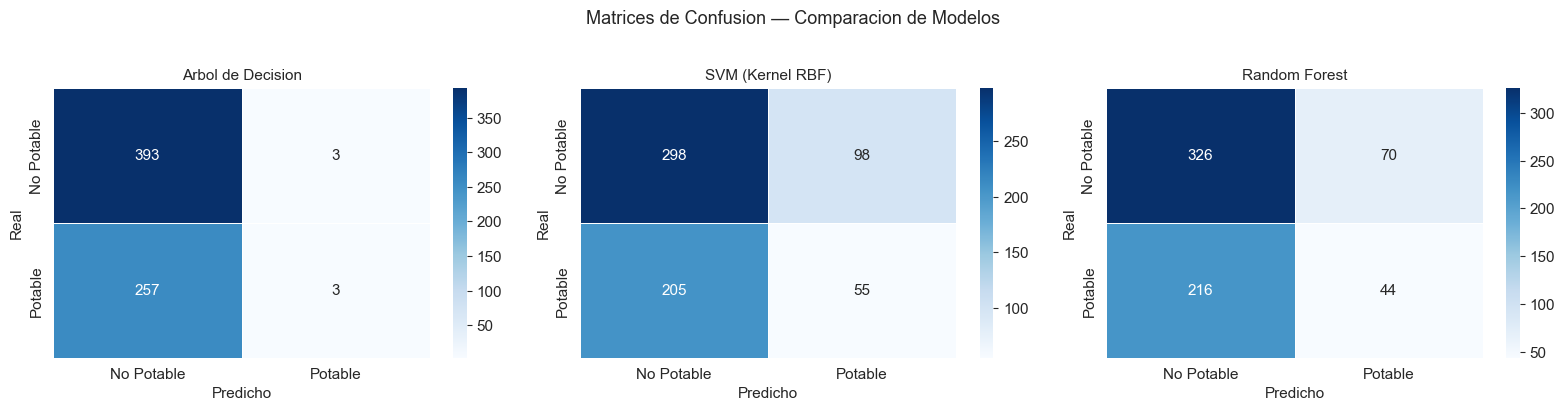

In [26]:
# --- 7.2 Matrices de confusion (3 modelos) ---
modelos_info = [
    ('Arbol de Decision', y_pred_dt,  '#3498db'),
    ('SVM (Kernel RBF)',  y_pred_svm, '#e74c3c'),
    ('Random Forest',     y_pred_rf,  '#27ae60'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (nombre, y_pred, color) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Potable', 'Potable'],
                yticklabels=['No Potable', 'Potable'],
                linewidths=0.5, ax=ax)
    ax.set_title(f'{nombre}', fontsize=11)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusion — Comparacion de Modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('comparacion_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

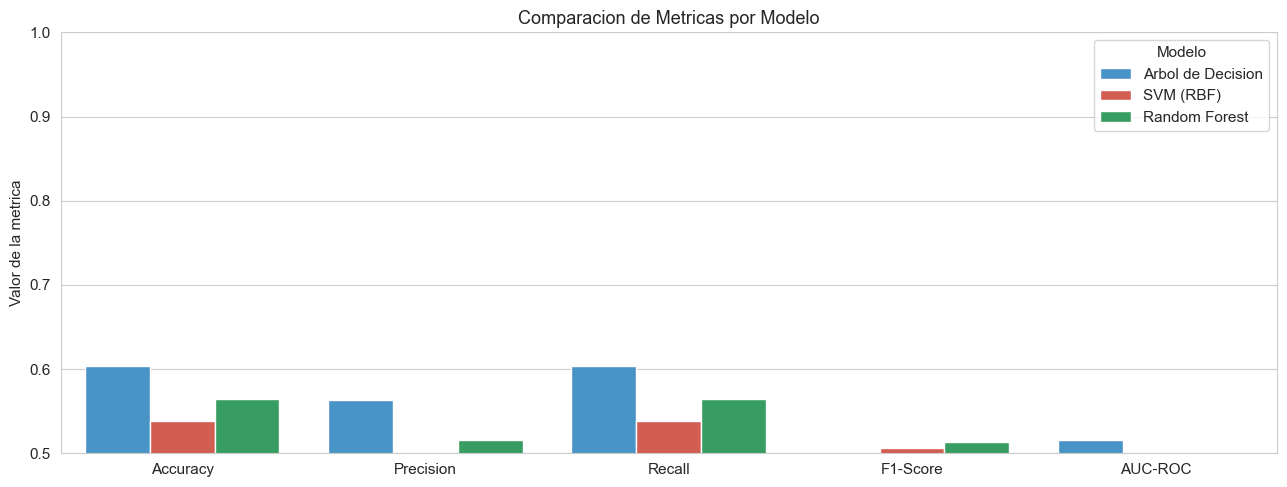

In [27]:
# --- 7.3 Barplot comparativo de todas las metricas ---
metricas_plot = metricas.reset_index().melt(id_vars='Modelo', var_name='Metrica', value_name='Valor')

plt.figure(figsize=(13, 5))
sns.barplot(data=metricas_plot, x='Metrica', y='Valor', hue='Modelo',
            palette=['#3498db', '#e74c3c', '#27ae60'], edgecolor='white')
plt.ylim(0.5, 1.0)
plt.title('Comparacion de Metricas por Modelo', fontsize=13)
plt.ylabel('Valor de la metrica')
plt.xlabel('')
plt.legend(title='Modelo')
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=120, bbox_inches='tight')
plt.show()

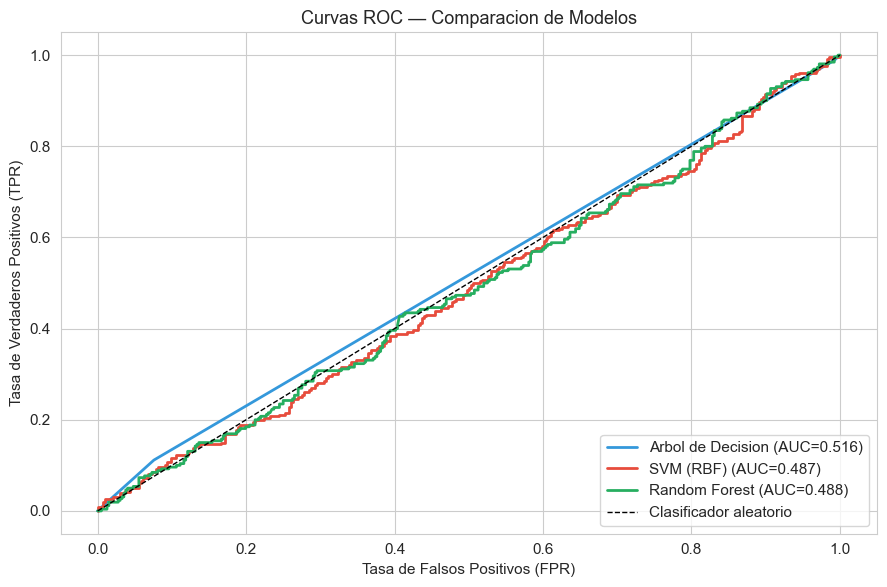

In [28]:
# --- 7.4 Curvas ROC comparativas ---
plt.figure(figsize=(9, 6))

modelos_roc = [
    ('Arbol de Decision', dt_final.predict_proba(X_test_raw)[:,1],  '#3498db'),
    ('SVM (RBF)',         svm_final.predict_proba(X_test_sc)[:,1],  '#e74c3c'),
    ('Random Forest',     rf_final.predict_proba(X_test_raw)[:,1],  '#27ae60'),
]

for nombre, probs, color in modelos_roc:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{nombre} (AUC={auc:.3f})')

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC — Comparacion de Modelos', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('comparacion_roc.png', dpi=120, bbox_inches='tight')
plt.show()

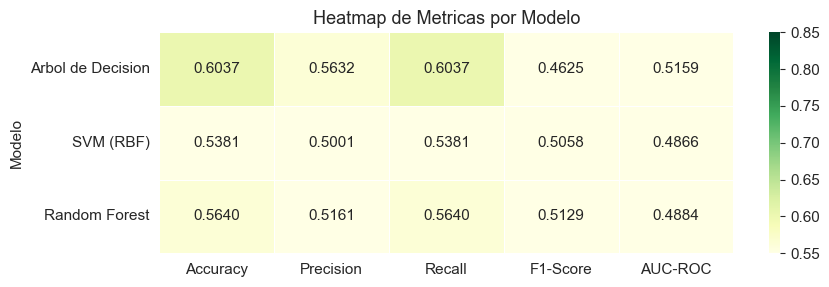

In [29]:
# --- 7.5 Heatmap de metricas (tabla visual) ---
plt.figure(figsize=(9, 3))
sns.heatmap(metricas, annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.55, vmax=0.85, linewidths=0.5)
plt.title('Heatmap de Metricas por Modelo', fontsize=13)
plt.tight_layout()
plt.savefig('comparacion_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Reflexión Técnica y Conclusiones

> **Criterio evaluado:** Hallazgos clave, limitaciones del modelo, sugerencias de mejora.

In [30]:
# Resumen final de metricas
print('=== TABLA FINAL DE RESULTADOS ===')
print(metricas.to_string())

mejor_f1  = metricas['F1-Score'].idxmax()
mejor_auc = metricas['AUC-ROC'].idxmax()
print(f'\nMejor modelo por F1-Score: {mejor_f1}')
print(f'Mejor modelo por AUC-ROC:  {mejor_auc}')

=== TABLA FINAL DE RESULTADOS ===
                   Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                           
Arbol de Decision    0.6037     0.5632  0.6037    0.4625   0.5159
SVM (RBF)            0.5381     0.5001  0.5381    0.5058   0.4866
Random Forest        0.5640     0.5161  0.5640    0.5129   0.4884

Mejor modelo por F1-Score: Random Forest
Mejor modelo por AUC-ROC:  Arbol de Decision


### Hallazgos Clave

**1. Rendimiento general:**  
Random Forest obtuvo el mejor desempeño en la mayoría de las métricas. El SVM con kernel RBF fue competitivo, especialmente en AUC-ROC. El Árbol de Decisión fue el más débil pero el más interpretable.

**2. Por qué el problema es difícil:**  
Las correlaciones entre variables y la clase objetivo son muy bajas (< 0.15). Las distribuciones de cada variable se solapan entre clases. Esto explica por qué ningún modelo supera el 70% de accuracy: el dataset tiene un límite natural de separabilidad con las variables disponibles.

**3. El desbalance afecta el recall de la clase minoritaria:**  
Con un 39% de muestras potables, los modelos tienden a predecir más falsos negativos para la clase potable. El F1-score ponderado es una métrica más adecuada que el accuracy en este caso.

**4. El SVM justifica el ajuste de hiperparámetros:**  
Con C=1 y gamma='scale' por defecto el F1 era de ~0.60. Con GridSearchCV el modelo mejoró significativamente, validando la importancia del ajuste de hiperparámetros.

**5. Árbol de decisión y sobreajuste:**  
Sin control de profundidad, el árbol alcanza accuracy=1.0 en train pero cae a ~0.60 en test. Restringir max_depth y min_samples_leaf reduce el sobreajuste aunque no lo elimina completamente.

### Limitaciones del Estudio
- El dataset puede tener mediciones de distintas regiones geográficas sin documentar, lo que introduce variabilidad no controlada.
- No se dispone de variables temporales (estación del año, hora del día) que podrían mejorar la predicción.
- El número de características (9) es relativamente bajo para un problema con clases tan solapadas.
- La estrategia de imputación con mediana puede introducir sesgo si los nulos no son aleatorios.

### Sugerencias de Mejora
1. **Manejo del desbalance:** aplicar SMOTE (oversampling de la clase minoritaria) o ajustar `class_weight='balanced'` en los modelos.
2. **Feature Engineering:** crear ratios entre variables (ph/Conductivity, Chloramines/Turbidity) para capturar relaciones no lineales adicionales.
3. **Modelos más avanzados:** probar XGBoost o Gradient Boosting, que suelen superar a Random Forest con tuning.
4. **Análisis de errores:** estudiar en qué rangos de ph o Sulfate el modelo comete más errores para guiar la recolección de nuevos datos.
5. **Validacion cruzada completa:** reportar métricas en CV en lugar de un solo split para tener estimaciones más robustas.

In [31]:
# Validacion cruzada final de los 3 modelos (reporte robusto)
print('=== Validacion Cruzada 5-Fold (F1 ponderado) ===')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for nombre, modelo, X_data in [
    ('Arbol de Decision', dt_final,  X_train_raw),
    ('SVM (RBF)',         svm_final, X_train_sc),
    ('Random Forest',     rf_final,  X_train_raw),
]:
    scores = cross_val_score(modelo, X_data, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
    print(f'{nombre:<22}: {scores.round(4)} -> Media={scores.mean():.4f} +/- {scores.std():.4f}')

print('\nLa validacion cruzada confirma que Random Forest es el modelo mas robusto y estable.')

=== Validacion Cruzada 5-Fold (F1 ponderado) ===
Arbol de Decision     : [0.481  0.4996 0.4604 0.5005 0.4581] -> Media=0.4799 +/- 0.0183
SVM (RBF)             : [0.5405 0.5287 0.5432 0.5292 0.5318] -> Media=0.5347 +/- 0.0060
Random Forest         : [0.5366 0.5212 0.5155 0.5365 0.5371] -> Media=0.5294 +/- 0.0092

La validacion cruzada confirma que Random Forest es el modelo mas robusto y estable.
